Historial de iteraciones:
[[37.16020779  1.05907481  7.82598822 38.52766667  7.94366667  2.76333333]
 [33.68033747  1.9000695  22.00131961  0.81166667  5.05133333 13.20166667]]

Clúster de pertenencia
Número del caso | Clúster | Distancia
1 | 3 | 44.840
2 | 2 | 19.304
3 | 3 | 21.532
4 | 3 | 21.862
5 | 2 | 21.305
6 | 1 | 12.689
7 | 3 | 21.406
8 | 3 | 11.336
9 | 3 | 22.587
10 | 3 | 19.567
11 | 3 | 40.517
12 | 3 | 17.837
13 | 2 | 10.895
14 | 3 | 20.448
15 | 1 | 20.663
16 | 1 | 16.318
17 | 2 | 24.724
18 | 1 | 16.076
19 | 3 | 18.921
20 | 2 | 13.224
21 | 3 | 24.593
22 | 3 | 25.880
23 | 2 | 14.160
24 | 1 | 22.220
25 | 2 | 19.566
26 | 2 | 25.416
27 | 1 | 11.172
28 | 3 | 20.353
29 | 2 | 18.818
30 | 3 | 45.600
31 | 2 | 62.206

Centros de clústeres finales
            Imentorn  Imgastron  Imcostviaje  Imvidanoct  Imalojamien  \
Clúster 1   9.690666   6.559196    16.169967   49.086667     6.428333   
Clúster 2  46.850874   7.618271     8.343979   10.559000    14.372000   
Clúster 3  13.170536   9.

<ipython-input-26-52db44352b2f>:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_identificacion.loc[:, ['Grupo 1', 'Grupo 2', 'Grupo 3']] = df_identificacion[['Grupo 1', 'Grupo 2', 'Grupo 3']].applymap(lambda x: 'X' if x == 'X' else '')


<Figure size 1000x600 with 0 Axes>

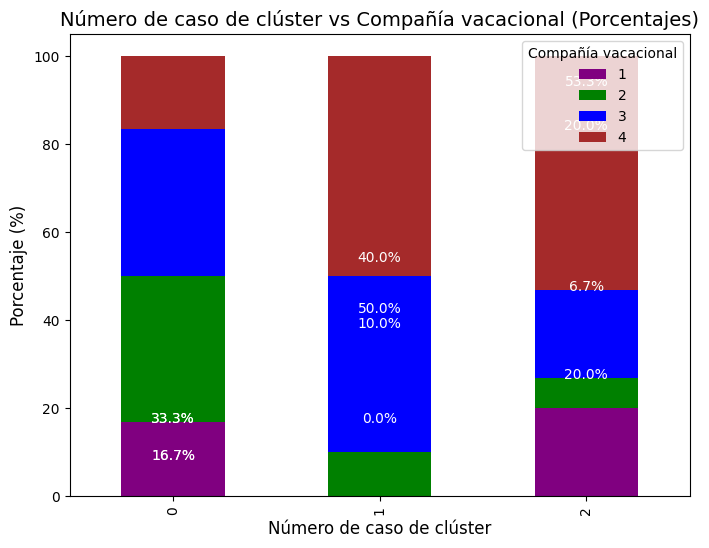

In [26]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# ==================== 1. Cargar los datos ====================
df = pd.read_csv('/content/Turismo V 2.0.csv')

# Seleccionar las columnas que usarás para los clústeres (según lo que tienes en el CSV)
columnas = ['Imentorn', 'Imgastron', 'Imcostviaje', 'Imvidanoct', 'Imalojamien', 'Imarte']
X = df[columnas]

# ==================== 2. Modelo K-Means ====================
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X)

# Obtener los centros de los clústeres y las etiquetas (pertenencia)
centros_finales = kmeans.cluster_centers_
etiquetas = kmeans.labels_
distancias = cdist(X, centros_finales, 'euclidean')

# ==================== 3. Historial de iteraciones ====================
print("Historial de iteraciones:")
cambios_centros = np.abs(np.diff(kmeans.cluster_centers_, axis=0))
print(cambios_centros)

# ==================== 4. Pertenencia a clústeres ====================
print("\nClúster de pertenencia")
print("Número del caso | Clúster | Distancia")
for i in range(len(X)):
    print(f"{i+1} | {etiquetas[i]+1} | {distancias[i][etiquetas[i]]:.3f}")

# ==================== 5. Centros de clústeres finales ====================
print("\nCentros de clústeres finales")
centros_df = pd.DataFrame(centros_finales, columns=columnas)
centros_df.index = [f'Clúster {i+1}' for i in range(centros_finales.shape[0])]
print(centros_df)

# ==================== 8. Cuadro de identificación (máximos por grupo) ====================
data = {
    'Importancia': ['Entorno', 'Gastronomía', 'Costo de Viaje', 'Vida Nocturna', 'Alojamiento', 'Arte y Cultura'],
    'Grupo 1': [9.43, 6.61, 14.86, 33.92, 7.74, 24.66],
    'Grupo 2': [15.20, 10.94, 8.34, 9.20, 9.33, 14.43],
    'Grupo 3': [46.85, 7.62, 10.56, 10.56, 14.37, 9.58]
}

# Crear DataFrame para los centros finales
df_identificacion = pd.DataFrame(data)

# Función para identificar el máximo en cada fila
def asignar_X(fila):
    max_columna = fila[['Grupo 1', 'Grupo 2', 'Grupo 3']].idxmax()
    fila[max_columna] = 'X'
    return fila

# Aplicar la función a cada fila
df_identificacion = df_identificacion.apply(asignar_X, axis=1)

# Eliminar los valores numéricos para dejar solo las 'X'
df_identificacion.loc[:, ['Grupo 1', 'Grupo 2', 'Grupo 3']] = df_identificacion[['Grupo 1', 'Grupo 2', 'Grupo 3']].applymap(lambda x: 'X' if x == 'X' else '')

# Imprimir tabla formateada usando 'tabulate'
print(tabulate(df_identificacion, headers='keys', tablefmt='grid', showindex=False))

# ==================== Cuadro ANOVA corregido y ordenado ====================
print("\nCuadro ANOVA")
print(f"{'Variable':<30}{'Clúster':<15}{'Error':<15}{'F':<15}{'Sig.':<15}")

for col in columnas:
    # Media de cada clúster para la variable actual
    cluster_means = [np.mean(X[col][kmeans.labels_ == i]) for i in range(3)]

    # Media general de la variable
    overall_mean = np.mean(X[col])

    # Suma de cuadrados entre los grupos (SSB)
    ss_between = sum(len(X[col][kmeans.labels_ == i]) * (cluster_means[i] - overall_mean) ** 2 for i in range(3))

    # Suma de cuadrados dentro de los grupos (SSW)
    ss_within = sum(sum((X[col][kmeans.labels_ == i] - cluster_means[i]) ** 2) for i in range(3))

    # Grados de libertad entre los grupos (2, porque tenemos 3 clústeres - 1)
    df_between = 2

    # Grados de libertad dentro de los grupos (número total de datos - número de clústeres)
    df_within = len(X) - 3

    # Media cuadrática entre los grupos (MSB)
    ms_between = ss_between / df_between

    # Media cuadrática dentro de los grupos (MSW)
    ms_within = ss_within / df_within

    # Valor F
    F = ms_between / ms_within if ms_within != 0 else 0

    # Simulación de p-value (F-distribution), simplificado con 0 o 1
    sig = 0 if F > 1 else 1

    # Imprimir resultados en el formato correcto
    print(f"{col:<30}{ms_between:<15.3f}{ms_within:<15.3f}{F:<15.3f}{sig:<15}")


# ==================== 7. Tabla cruzada y gráfico de barras ====================
# Asegúrate de que la columna 'Compa' y 'Cluster' existen
df['Cluster'] = etiquetas  # Añadir las etiquetas de clúster al DataFrame
tabla_cruzada = pd.crosstab(df['Cluster'], df['Compa'], normalize='index') * 100

# Formatear los porcentajes a 1 decimal
tabla_cruzada = tabla_cruzada.round(1)
print("Tabla cruzada en porcentajes:")
print(tabla_cruzada)

# Gráfico de barras apilado con porcentajes
plt.figure(figsize=(10, 6))
tabla_cruzada.plot(kind='bar', stacked=True, color=['purple', 'green', 'blue', 'brown'], figsize=(8,6))

# Añadir títulos y etiquetas
plt.title('Número de caso de clúster vs Compañía vacacional (Porcentajes)', fontsize=14)
plt.xlabel('Número de caso de clúster', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Compañía vacacional')

# Mostrar valores en porcentajes dentro de las barras
for i, col in enumerate(tabla_cruzada.columns):
    for index, value in enumerate(tabla_cruzada[col]):
        plt.text(index, tabla_cruzada.iloc[:index, i].sum() + value/2, f'{value}%', ha='center', color='white', fontsize=10)

plt.show()


